In [1]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from data_science_utilities.models.xgb.hyperparameter_search.random_search import OptimalXGBHyperparameterSearch

In [2]:
RANDOM_SEED = 32
# RFE on the directional (phase 2) pool recommends 57 features (get_best_num_features(.005)); see rfe.ipynb
BEST_NUM_FEATS = 57
TARGET = 'target_win'

RANDOM_XGB_PARAMS = {
    # How fast the model learns. The smaller, the more likely to get stuck in local minima, but the larger, the more likely to overshoot the global minima
    'learning_rate': [.03, .05, .1, .15, .2],
    # How deep the tree can be. The deeper, the more likely to overfit and more complex
    'max_depth': [2, 3],
    # The fraction of samples to be used for fitting the individual base learners. 
    # Values lower than 1 make the model more robust by preventing overfitting
    'subsample': [.5, .7, .9],
    # The minimum number of samples required to be at a leaf node. The larger, the more conservative
    'min_child_weight': [10, 20, 50, 100],
    # Minimum loss reduction required to make a split on a leaf node of the tree. Attempts to only split when it makes a significant improvement
    'gamma': [.5, 1, 5, 10, 100],
    # The number of trees to be used in the model. The more, the more likely to overfit
    'n_estimators': [10, 20,30, 40, 50],
    # The number of iterations the model can't improve before stopping
    'early_stopping_rounds': [10, 20, 50],
    # The way the model calculates the importance of each feature. Total gain is the sum of the gain of each feature used in the model
    'importance_type': ['total_gain'],
    # The evaluation metric to be used. AUC measures how well the model is able to distinguish between classes (win or loss)
    'eval_metric': ['auc']
}

RANDOM_SEARCH_PARAMS = dict(
    n_iter=100,
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    scoring='roc_auc',
)

BEST_FEATS_FROM_RFE = list(pd.read_csv(
    '../../../../../data/predict_games/model_features_in/rfe_features_kfolds.csv',
    index_col=0
).loc[BEST_NUM_FEATS, :].dropna().values)

MODEL_INPUTS_DF = pd.read_parquet(
    '../../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
)

MODEL_INPUTS_DF = MODEL_INPUTS_DF.sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)

np.random.seed(RANDOM_SEED)

In [3]:
# Two-season holdout: train on everything before 2022, use 2022-2023 as the early-stopping
# test slice, and hold out 2024+2025 (the original 3-way split shifted one year forward).
train_df = MODEL_INPUTS_DF[(MODEL_INPUTS_DF['season'] < 2022)]
test_df = MODEL_INPUTS_DF[
    (MODEL_INPUTS_DF['season'] >= 2022) & (MODEL_INPUTS_DF['season'] < 2024)
]
holdout_df = MODEL_INPUTS_DF[MODEL_INPUTS_DF['season'] >= 2024].copy()
X_train = train_df[BEST_FEATS_FROM_RFE]
y_train = train_df[TARGET]
X_test = test_df[BEST_FEATS_FROM_RFE]
y_test = test_df[TARGET]
X_holdout = holdout_df[BEST_FEATS_FROM_RFE]
y_holdout = holdout_df[TARGET]

In [4]:
rand_hyperparam_search = OptimalXGBHyperparameterSearch(
    X_train, y_train, X_test, y_test
)

In [5]:
rand_search = rand_hyperparam_search.search(
    RANDOM_XGB_PARAMS, **RANDOM_SEARCH_PARAMS
)

[0]	validation_0-auc:0.61376	validation_1-auc:0.59689
[1]	validation_0-auc:0.63019	validation_1-auc:0.61033
[2]	validation_0-auc:0.65235	validation_1-auc:0.63063
[3]	validation_0-auc:0.65470	validation_1-auc:0.63445
[4]	validation_0-auc:0.65834	validation_1-auc:0.64110
[5]	validation_0-auc:0.66504	validation_1-auc:0.64601
[6]	validation_0-auc:0.66689	validation_1-auc:0.64849
[7]	validation_0-auc:0.67050	validation_1-auc:0.64950
[0]	validation_0-auc:0.63456	validation_1-auc:0.62481
[8]	validation_0-auc:0.67060	validation_1-auc:0.65113
[0]	validation_0-auc:0.63445	validation_1-auc:0.61325
[0]	validation_0-auc:0.63188	validation_1-auc:0.61176
[1]	validation_0-auc:0.65865	validation_1-auc:0.64172
[0]	validation_0-auc:0.63022	validation_1-auc:0.59728
[9]	validation_0-auc:0.66937	validation_1-auc:0.64990
[1]	validation_0-auc:0.65380	validation_1-auc:0.62726
[1]	validation_0-auc:0.65398	validation_1-auc:0.61323
[2]	validation_0-auc:0.66796	validation_1-auc:0.64462
[1]	validation_0-auc:0.65807

[32]	validation_0-auc:0.71383	validation_1-auc:0.65913
[25]	validation_0-auc:0.72955	validation_1-auc:0.65068
[24]	validation_0-auc:0.68889	validation_1-auc:0.66135
[33]	validation_0-auc:0.71729	validation_1-auc:0.66197
[19]	validation_0-auc:0.68140	validation_1-auc:0.66010
[16]	validation_0-auc:0.71902	validation_1-auc:0.66309
[16]	validation_0-auc:0.71870	validation_1-auc:0.66065
[21]	validation_0-auc:0.72237	validation_1-auc:0.65517
[37]	validation_0-auc:0.71944	validation_1-auc:0.65351
[33]	validation_0-auc:0.71405	validation_1-auc:0.65863
[37]	validation_0-auc:0.71858	validation_1-auc:0.66954
[28]	validation_0-auc:0.69105	validation_1-auc:0.66129
[30]	validation_0-auc:0.71422	validation_1-auc:0.65417
[25]	validation_0-auc:0.68944	validation_1-auc:0.66080
[30]	validation_0-auc:0.69192	validation_1-auc:0.65500
[34]	validation_0-auc:0.71729	validation_1-auc:0.66197
[17]	validation_0-auc:0.72007	validation_1-auc:0.66412
[17]	validation_0-auc:0.71911	validation_1-auc:0.66005
[38]	valid

[4]	validation_0-auc:0.66726	validation_1-auc:0.64537
[9]	validation_0-auc:0.69635	validation_1-auc:0.66199
[14]	validation_0-auc:0.70471	validation_1-auc:0.66379
[27]	validation_0-auc:0.72571	validation_1-auc:0.66557
[1]	validation_0-auc:0.63724	validation_1-auc:0.62361
[21]	validation_0-auc:0.71542	validation_1-auc:0.65849
[6]	validation_0-auc:0.66623	validation_1-auc:0.64325
[0]	validation_0-auc:0.61564	validation_1-auc:0.61309
[14]	validation_0-auc:0.70599	validation_1-auc:0.66191
[14]	validation_0-auc:0.70441	validation_1-auc:0.64919
[2]	validation_0-auc:0.66286	validation_1-auc:0.64584
[5]	validation_0-auc:0.67065	validation_1-auc:0.64952
[10]	validation_0-auc:0.69758	validation_1-auc:0.66022
[2]	validation_0-auc:0.65201	validation_1-auc:0.62267
[15]	validation_0-auc:0.70527	validation_1-auc:0.66427
[1]	validation_0-auc:0.62911	validation_1-auc:0.62756
[2]	validation_0-auc:0.64726	validation_1-auc:0.63784
[22]	validation_0-auc:0.71634	validation_1-auc:0.65846
[15]	validation_0-au

[42]	validation_0-auc:0.70332	validation_1-auc:0.67020
[43]	validation_0-auc:0.70482	validation_1-auc:0.65891
[42]	validation_0-auc:0.70199	validation_1-auc:0.66574
[11]	validation_0-auc:0.69423	validation_1-auc:0.66727
[46]	validation_0-auc:0.70528	validation_1-auc:0.66212
[7]	validation_0-auc:0.68421	validation_1-auc:0.64972
[1]	validation_0-auc:0.63692	validation_1-auc:0.62155
[11]	validation_0-auc:0.69249	validation_1-auc:0.66759
[5]	validation_0-auc:0.67967	validation_1-auc:0.65680
[43]	validation_0-auc:0.70589	validation_1-auc:0.65998
[43]	validation_0-auc:0.70374	validation_1-auc:0.66983
[44]	validation_0-auc:0.70497	validation_1-auc:0.65881
[43]	validation_0-auc:0.70220	validation_1-auc:0.66519
[12]	validation_0-auc:0.69443	validation_1-auc:0.66641
[0]	validation_0-auc:0.57065	validation_1-auc:0.56354
[8]	validation_0-auc:0.68666	validation_1-auc:0.65151
[12]	validation_0-auc:0.69403	validation_1-auc:0.66717
[6]	validation_0-auc:0.68390	validation_1-auc:0.65755
[2]	validation_0

[7]	validation_0-auc:0.63649	validation_1-auc:0.62215
[14]	validation_0-auc:0.69031	validation_1-auc:0.65671
[20]	validation_0-auc:0.61394	validation_1-auc:0.59714
[23]	validation_0-auc:0.64525	validation_1-auc:0.62993
[18]	validation_0-auc:0.69283	validation_1-auc:0.65698
[19]	validation_0-auc:0.64130	validation_1-auc:0.64073
[28]	validation_0-auc:0.64257	validation_1-auc:0.62139
[3]	validation_0-auc:0.63601	validation_1-auc:0.62243
[12]	validation_0-auc:0.68912	validation_1-auc:0.65160
[5]	validation_0-auc:0.64293	validation_1-auc:0.63149
[8]	validation_0-auc:0.67442	validation_1-auc:0.65562
[8]	validation_0-auc:0.63649	validation_1-auc:0.62215
[21]	validation_0-auc:0.61394	validation_1-auc:0.59714
[24]	validation_0-auc:0.64148	validation_1-auc:0.62638
[19]	validation_0-auc:0.69408	validation_1-auc:0.65634
[20]	validation_0-auc:0.63973	validation_1-auc:0.63886
[19]	validation_0-auc:0.69536	validation_1-auc:0.66196
[4]	validation_0-auc:0.63601	validation_1-auc:0.62243
[13]	validation_

...

[46]	validation_0-auc:0.72634	validation_1-auc:0.66021


[47]	validation_0-auc:0.72666	validation_1-auc:0.66095


[48]	validation_0-auc:0.72688	validation_1-auc:0.66040


[49]	validation_0-auc:0.72745	validation_1-auc:0.66063




Best parameters found:  {'subsample': 0.5, 'n_estimators': 50, 'min_child_weight': 50, 'max_depth': 3, 'learning_rate': 0.1, 'importance_type': 'total_gain', 'gamma': 1, 'eval_metric': 'auc', 'early_stopping_rounds': 50}


Best score found:  0.685217816123133


Best Selected Features:  ['is_home_target', 'opp_def_cumulative_avg_points_allowed_rank', 'def_opp_rushing_yards_cumulative_average_rank', 'opp_off_cumulative_avg_score_rank', 'off_target_third_down_conversion_rate_garbage_trailing_cumulative_average_rank', 'def_opp_run_right_end_yards_per_attempt_garbage_trailing_cumulative_average_rank', 'target_off_cumulative_avg_score_rank', 'def_target_run_right_end_explosive_rate_garbage_trailing_cumulative_average_rank', 'off_target_success_rate_competitive_cumulative_average_rank', 'off_opp_pass_success_rate_competitive_cumulative_average_rank', 'target_def_cumulative_avg_points_allowed_rank', 'off_opp_success_rate_competitive_cumulative_average_rank', 'def_opp_run_right_tackle_explosi

In [6]:
# view all the scores from the search
rand_search.cv_results_

{'mean_fit_time': array([0.25978599, 0.279037  , 0.26249471, 0.26768694, 0.30216308,
        0.10526447, 0.16190882, 0.14876237, 0.26000061, 0.22040367,
        0.10022674, 0.10226779, 0.24072061, 0.21340322, 0.26536031,
        0.14913335, 0.15501022, 0.1750751 , 0.16066718, 0.10365338,
        0.10876117, 0.16561756, 0.22683358, 0.20768805, 0.19579663,
        0.28605223, 0.16025562, 0.14301038, 0.21509957, 0.20692444,
        0.18527603, 0.28975186, 0.17253375, 0.24645424, 0.10664172,
        0.09948215, 0.16080871, 0.19659033, 0.10426254, 0.15571699,
        0.23904023, 0.30074372, 0.12141776, 0.1464066 , 0.19682989,
        0.09755225, 0.10586877, 0.14002299, 0.17693267, 0.23921628,
        0.19689479, 0.10307245, 0.29121761, 0.0952189 , 0.24590945,
        0.16812887, 0.30980878, 0.10182939, 0.23428164, 0.12008615,
        0.19136796, 0.19092727, 0.09793997, 0.10095601, 0.15387063,
        0.18512068, 0.12232037, 0.15207658, 0.2067317 , 0.28358493,
        0.18360763, 0.14853597,

<Axes: >

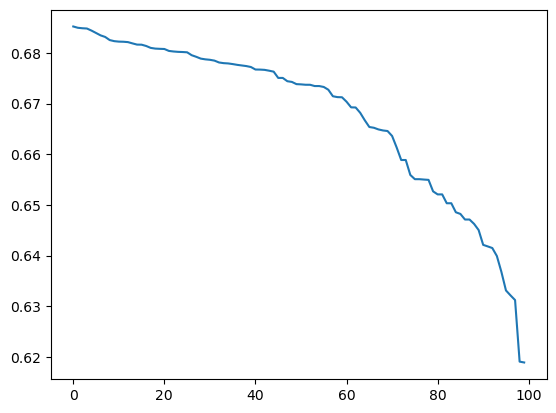

In [7]:
# Graph the search results. Make the index the rank of the score
# another column for the mean test score
rand_search_results = pd.DataFrame(rand_search.cv_results_)
rand_search_results['rank_test_score'] = rand_search_results['rank_test_score']
rand_search_results['mean_test_score'] = rand_search_results['mean_test_score']
rand_search_results = rand_search_results.sort_values(by='rank_test_score', ascending=True)
rand_search_results = rand_search_results.reset_index(drop=True)
rand_search_results['mean_test_score'].plot()

In [8]:
# What are the grid search params for the top 5 scores?
rand_search_results.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_importance_type,...,param_early_stopping_rounds,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.309809,0.063125,0.003988,0.001072,0.5,50,50,3,0.1,total_gain,...,50,"{'subsample': 0.5, 'n_estimators': 50, 'min_ch...",0.688578,0.682212,0.677904,0.683666,0.693729,0.685218,0.005453,1
1,0.226493,0.029472,0.003160,0.000117,0.7,40,10,3,0.1,total_gain,...,10,"{'subsample': 0.7, 'n_estimators': 40, 'min_ch...",0.687566,0.681220,0.680046,0.683221,0.692755,0.684962,0.004663,2
2,0.274584,0.031299,0.004305,0.002141,0.5,50,20,3,0.05,total_gain,...,20,"{'subsample': 0.5, 'n_estimators': 50, 'min_ch...",0.688284,0.675783,0.678082,0.685200,0.696993,0.684868,0.007582,3
3,0.289752,0.025601,0.004196,0.002036,0.7,50,20,3,0.1,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 50, 'min_ch...",0.687856,0.681720,0.679492,0.682235,0.692771,0.684815,0.004840,4
4,0.206924,0.022503,0.003807,0.001520,0.9,30,10,3,0.1,total_gain,...,20,"{'subsample': 0.9, 'n_estimators': 30, 'min_ch...",0.694251,0.677728,0.682627,0.680464,0.686958,0.684406,0.005775,5


In [9]:
# save the json of the best model
best_model = rand_search.best_estimator_
best_model.save_model(
    os.path.join(module_path, 'models', 'best_random_xgb_model.json')
)

In [10]:
# What is the score on the holdout set?
best_model.score(X_holdout, y_holdout)

0.6452205882352942

In [11]:
holdout_df.loc[:, 'preds'] = best_model.predict_proba(X_holdout)[:, 1]

In [12]:
# Show the predictions for the holdout set
results_df = holdout_df[
    ['game_id', 'week', 'target_team', 'opp_team', 'target_win', 'preds']
].copy()
results_df.sort_values(by='game_id', inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,game_id,week,target_team,opp_team,target_win,preds
0,2024_01_ARI_BUF,1,ARI,BUF,0,0.342936
1,2024_01_ARI_BUF,1,BUF,ARI,1,0.657614
2,2024_01_BAL_KC,1,KC,BAL,1,0.511472
3,2024_01_BAL_KC,1,BAL,KC,0,0.471751
4,2024_01_CAR_NO,1,CAR,NO,0,0.350868
...,...,...,...,...,...,...
1083,2025_18_SEA_SF,18,SF,SEA,0,0.551519
1084,2025_18_TEN_JAX,18,JAX,TEN,1,0.660539
1085,2025_18_TEN_JAX,18,TEN,JAX,0,0.340081
1086,2025_18_WAS_PHI,18,PHI,WAS,0,0.654800


week
1     0.910156
2     0.727539
3     0.553711
4     0.623047
5     0.422194
6     0.720571
7     0.836667
8     0.713436
9     0.714625
10    0.688776
11    0.725327
12    0.734568
13    0.745117
14    0.720165
15    0.781250
16    0.622070
17    0.641602
18    0.632812
dtype: float64

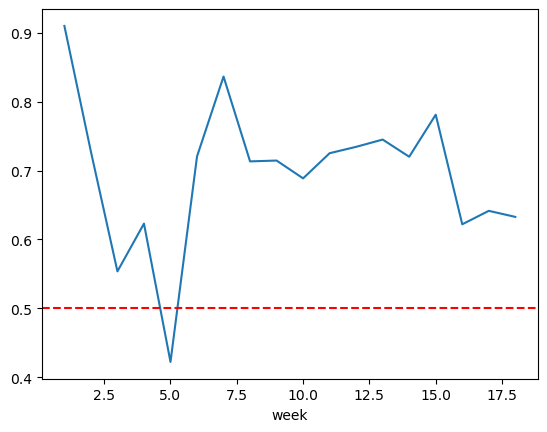

In [13]:
# get the AUROC score by week
weekly_scores = holdout_df.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

In [14]:
# for each game_id, only keep the higher prediction
higher_preds = holdout_df.groupby('game_id').apply(
    lambda x: x.loc[x['preds'].idxmax(), :],
    include_groups=False
)
higher_preds.reset_index(drop=True, inplace=True)

week
1     0.660714
2     0.631818
3     0.714844
4     0.635294
5     0.534759
6     0.452381
7     0.755682
8     0.583333
9     0.392857
10    0.473684
11    0.712121
12    0.525000
13    0.645022
14    0.464286
15    0.550725
16    0.543651
17    0.428571
18    0.634921
dtype: float64

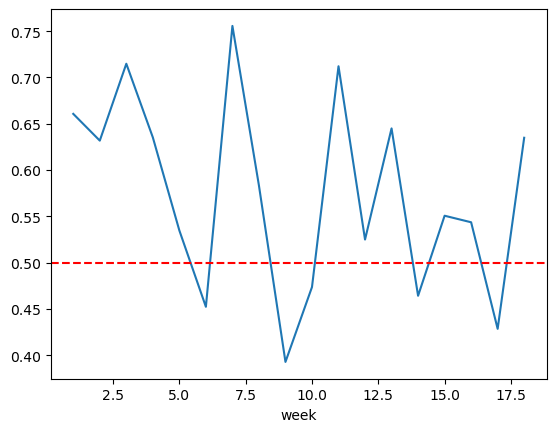

In [15]:
# get the AUROC score by week
weekly_scores = higher_preds.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

## How good are the model's *confident* predictions?

AUROC only measures **ranking** (can the model sort winners above losers?). It says
nothing about whether a 0.80 prediction is actually right ~80% of the time. The cells
below answer "when the model has a strong prediction, how well does it predict?" using:

1. **Brier score & log loss** — residual-based metrics that penalize overconfidence.
2. **Confidence-bucketed accuracy** — the direct answer: how often the favored team wins,
   grouped by how sure the model was.
3. **Reliability diagram** — visual calibration check (predicted prob vs observed win rate).

Note: `holdout_df` has two rows per `game_id` (one per team). Brier/log loss are computed
on all rows consistently; the bucketed-accuracy table uses the one-row-per-game `higher_preds`
frame so each game is counted once.

In [16]:
# Residual-based metrics. Unlike AUROC, these penalize confident-and-wrong predictions.
from sklearn.metrics import brier_score_loss, log_loss

brier = brier_score_loss(holdout_df['target_win'], holdout_df['preds'])
ll = log_loss(holdout_df['target_win'], holdout_df['preds'])
print(f"Brier score: {brier:.4f}  (lower is better; 0.25 = coin flip)")
print(f"Log loss:    {ll:.4f}  (lower is better; punishes confident-and-wrong hardest)")

Brier score: 0.2291  (lower is better; 0.25 = coin flip)
Log loss:    0.6507  (lower is better; punishes confident-and-wrong hardest)


In [17]:
# Confidence-bucketed accuracy: the direct answer to "when the model is confident, is it right?"
# On higher_preds, `preds` is the model's confidence in its pick (0.5-1.0) and
# target_win == 1 means the favored team actually won.
higher_preds['confidence'] = higher_preds['preds']
higher_preds['bucket'] = pd.cut(
    higher_preds['confidence'], bins=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
)

confidence_summary = higher_preds.groupby('bucket', observed=True).agg(
    n_games=('target_win', 'size'),
    pick_accuracy=('target_win', 'mean'),   # how often the favored team won
    avg_confidence=('confidence', 'mean'),  # what the model claimed
)
# Positive gap = overconfident (claimed more than it delivered)
confidence_summary['calibration_gap'] = (
    confidence_summary['avg_confidence'] - confidence_summary['pick_accuracy']
)
confidence_summary

,n_games,pick_accuracy,avg_confidence,calibration_gap
bucket,,,,
"(0.5, 0.6]",400,0.635000,0.549225,-0.085775
"(0.6, 0.7]",123,0.723577,0.631105,-0.092473


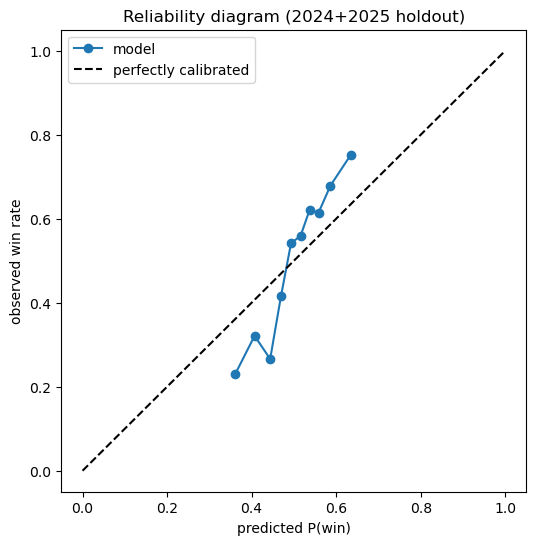

In [18]:
# Reliability diagram: are the probabilities trustworthy?
# Points on the diagonal = perfectly calibrated. Below the diagonal on the right
# side = the model is overconfident when bullish.
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    holdout_df['target_win'], holdout_df['preds'], n_bins=10, strategy='quantile'
)
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='model')
plt.plot([0, 1], [0, 1], 'k--', label='perfectly calibrated')
plt.xlabel('predicted P(win)')
plt.ylabel('observed win rate')
plt.title('Reliability diagram (2024+2025 holdout)')
plt.legend()
plt.show()

## Does a wider home-vs-away gap mean better predictions?

Each game has two predictions: `P(home wins)` from the home-perspective row and
`P(away wins)` from the away-perspective row. The **gap** between them is a stronger
confidence signal than `max(pred)` alone — it uses *both* perspectives. A wide gap
means the two views agree strongly on a winner; a narrow gap means the model is torn.

Hypothesis: when the gap is wide, accuracy should be higher. We pivot the two rows onto
one row per game (via `is_home_target`), define the model's pick as whichever side has
the higher probability, and bucket accuracy by gap width (quintiles, so every bin is
populated).

In [19]:
# Pivot the two perspectives of each game onto one row (is_home_target: 1 = home, 0 = away)
game_view = holdout_df.pivot_table(
    index='game_id', columns='is_home_target', values=['preds', 'target_win'], aggfunc='first'
).dropna()

games = pd.DataFrame({
    'home_pred': game_view[('preds', 1)],
    'away_pred': game_view[('preds', 0)],
    'home_won':  game_view[('target_win', 1)].astype(int),
})
games['gap']           = games['home_pred'] - games['away_pred']   # >0 leans home, <0 leans away
games['abs_gap']       = games['gap'].abs()                        # strength of the lean
games['pred_home_win'] = games['home_pred'] > games['away_pred']
games['correct']       = games['pred_home_win'] == (games['home_won'] == 1)

# Bucket by gap width (quintiles) and measure accuracy in each
games['gap_quintile'] = pd.qcut(games['abs_gap'], 5)
gap_summary = games.groupby('gap_quintile', observed=True).agg(
    n_games=('correct', 'size'),
    mean_abs_gap=('abs_gap', 'mean'),
    accuracy=('correct', 'mean'),
)
print(f"Overall correlation(abs_gap, correct): {games['abs_gap'].corr(games['correct'].astype(int)):.3f}")
gap_summary

Overall correlation(abs_gap, correct): 0.174


,n_games,mean_abs_gap,accuracy
gap_quintile,,,
"(-0.0006770000000000001, 0.0475]",109,0.024223,0.568807
"(0.0475, 0.0881]",109,0.067928,0.559633
"(0.0881, 0.137]",108,0.110732,0.666667
"(0.137, 0.213]",109,0.176286,0.715596
"(0.213, 0.397]",109,0.266904,0.761468


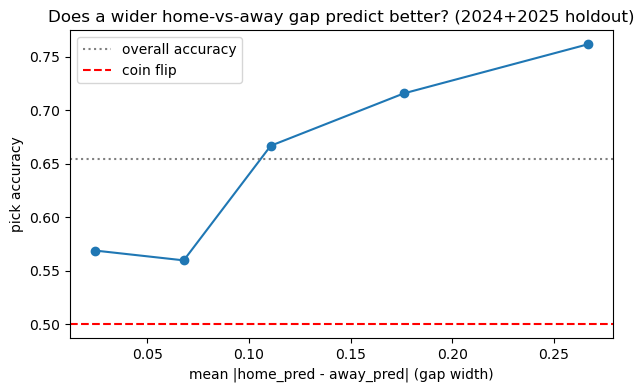

In [20]:
# Visualize the hypothesis: accuracy should rise as the home-vs-away gap widens
plt.figure(figsize=(7, 4))
plt.plot(gap_summary['mean_abs_gap'], gap_summary['accuracy'], marker='o')
plt.axhline(y=games['correct'].mean(), color='gray', linestyle=':', label='overall accuracy')
plt.axhline(y=0.5, color='r', linestyle='--', label='coin flip')
plt.xlabel('mean |home_pred - away_pred| (gap width)')
plt.ylabel('pick accuracy')
plt.title('Does a wider home-vs-away gap predict better? (2024+2025 holdout)')
plt.legend()
plt.show()